* [#31](https://github.com/salgo60/ifkdb/issues/31)
* Denna Notebok [31_sodrasajten](https://github.com/salgo60/ifkdb/blob/main/Notebook/31_sodrasajten.ipynb)

In [1]:
from datetime import datetime
import platform
import sys
import os

# Start timer
start_time = datetime.now()
print(f"Start time: {start_time:%Y-%m-%d %H:%M:%S}")


Start time: 2026-03-03 14:01:22


In [2]:
import os

print(os.getcwd())

/Users/salgo/Documents/GitHub/ifkdb/Notebook


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from SPARQLWrapper import SPARQLWrapper, JSON
import re
from unidecode import unidecode

HEADERS = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "sv-SE,sv;q=0.9,en;q=0.8"
}

def normalize(name):
    name = unidecode(name.lower())
    name = re.sub(r"[^a-z\s-]", "", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name


# ---------------------------------------------------
# 1. Södrasajten – textbaserad extraction
# ---------------------------------------------------

def scrape_sodrasajten():
    url = "https://www.sodrasajten.se/lagbygget-2024/"
    r = requests.get(url, headers=HEADERS)

    print("Södrasajten status:", r.status_code)

    soup = BeautifulSoup(r.text, "html.parser")

    text_lines = soup.get_text("\n").split("\n")

    players = []

    for line in text_lines:
        line = line.strip()

        # namn = minst två ord med versal början
        if re.match(r"^[A-ZÅÄÖ][a-zåäöA-ZÅÄÖ\-]+ [A-ZÅÄÖ][a-zåäöA-ZÅÄÖ\-]+", line):
            if len(line.split()) <= 3:  # undvik långa meningar
                players.append(line)

    players = sorted(list(set(players)))

    print("Hittade kandidater:", len(players))
    return players


# ---------------------------------------------------
# 2. Wikipedia (med korrekt UA)
# ---------------------------------------------------

import mwclient

def fetch_wikipedia_category():
    site = mwclient.Site('sv.wikipedia.org')
    
    category = site.categories['Fotbollsspelare_i_Jönköpings_Södra_IF']
    
    players = []
    
    for page in category.members():
        if page.namespace == 0:  # endast artiklar
            players.append(page.name)
    
    print("Wikipedia-kategori spelare:", len(players))
    return players

wiki_players = fetch_wikipedia_category()
wiki_players[:10]  



# ---------------------------------------------------
# 3. Wikidata
# ---------------------------------------------------

def wikidata_players():
    sparql = SPARQLWrapper("https://query.wikidata.org/sparql")
    sparql.setQuery("""
    SELECT ?player ?playerLabel WHERE {
      ?player wdt:P54 wd:Q931714.
      SERVICE wikibase:label { bd:serviceParam wikibase:language "sv,mul,en". }
    }
    """)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()

    players = []
    for r in results["results"]["bindings"]:
        label = r["playerLabel"]["value"]
        qid = r["player"]["value"].split("/")[-1]
        players.append((label, qid))

    print("Wikidata spelare:", len(players))
    return players


# ---------------------------------------------------
# 4. Kör
# ---------------------------------------------------

sodra = scrape_sodrasajten()
wiki_players = fetch_wikipedia_category()
wd = wikidata_players()

wiki_set = {normalize(n) for n in wiki_players}
wd_dict = {normalize(label): (label, qid) for label, qid in wd}

rows = []

for name in sodra:
    norm = normalize(name)

    wiki_match = norm in wiki_set
    wd_match = wd_dict.get(norm)

    rows.append({
        "Player": name,
        "Wikipedia category": "✅" if wiki_match else "❌",
        "Wikidata P54": f"[{wd_match[0]}](https://www.wikidata.org/wiki/{wd_match[1]})" if wd_match else "❌"
    })

df = pd.DataFrame(rows).sort_values("Player")

df

Wikipedia-kategori spelare: 153
Södrasajten status: 200
Hittade kandidater: 49
Wikipedia-kategori spelare: 153
Wikidata spelare: 191


,Player,Wikipedia category,Wikidata P54
0,Agon Uka,❌,❌
1,Alexander Eriksson,❌,❌
2,Andreas Karlsson,❌,❌
3,Anmar Kiwarkis,❌,❌
4,Arvid Eriksson,❌,[Arvid Eriksson](https://www.wikidata.org/wiki...
5,Assyriska Turabdin IK,❌,❌
6,Axel Edgren,❌,❌
7,Bankeryds SK,❌,❌
8,Benjamin Tannus,✅,[Benjamin Tannus](https://www.wikidata.org/wik...
9,Bäckseda IF,❌,❌


In [4]:
import re
import pandas as pd
from unidecode import unidecode

# ------------------------------
# Normalisering
# ------------------------------

def clean_wiki_name(name):
    # Ta bort parenteser: "Samuel Adrian (fotbollsspelare)"
    name = re.sub(r"\s*\(.*?\)", "", name)
    return name.strip()

def normalize(name):
    name = unidecode(name.lower())
    name = re.sub(r"[^a-z\s-]", "", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name


# ------------------------------
# Förbered data
# ------------------------------

wiki_clean = [clean_wiki_name(n) for n in wiki_players]

wiki_set = {normalize(n) for n in wiki_clean}
wd_dict = {normalize(label): (label, qid) for label, qid in wd}

# ------------------------------
# Matchning
# ------------------------------

rows = []

for name in sodra:
    norm = normalize(name)

    wiki_match = norm in wiki_set
    wd_match = wd_dict.get(norm)

    rows.append({
        "Player": name,
        "Wikipedia category": "✅" if wiki_match else "❌",
        "Wikidata P54": f"[{wd_match[0]}](https://www.wikidata.org/wiki/{wd_match[1]})" if wd_match else "❌"
    })

df = pd.DataFrame(rows).sort_values("Player")

df

,Player,Wikipedia category,Wikidata P54
0,Agon Uka,❌,❌
1,Alexander Eriksson,❌,❌
2,Andreas Karlsson,❌,❌
3,Anmar Kiwarkis,❌,❌
4,Arvid Eriksson,✅,[Arvid Eriksson](https://www.wikidata.org/wiki...
5,Assyriska Turabdin IK,❌,❌
6,Axel Edgren,❌,❌
7,Bankeryds SK,❌,❌
8,Benjamin Tannus,✅,[Benjamin Tannus](https://www.wikidata.org/wik...
9,Bäckseda IF,❌,❌


In [5]:
print(df.to_markdown(index=False))

| Player                 | Wikipedia category   | Wikidata P54                                               |
|:-----------------------|:---------------------|:-----------------------------------------------------------|
| Agon Uka               | ❌                   | ❌                                                         |
| Alexander Eriksson     | ❌                   | ❌                                                         |
| Andreas Karlsson       | ❌                   | ❌                                                         |
| Anmar Kiwarkis         | ❌                   | ❌                                                         |
| Arvid Eriksson         | ✅                   | [Arvid Eriksson](https://www.wikidata.org/wiki/Q115327693) |
| Assyriska Turabdin IK  | ❌                   | ❌                                                         |
| Axel Edgren            | ❌                   | ❌                                                         |
| Bankeryds SK

In [6]:
print("Totalt Södrasajten:", len(sodra))
print("Match Wikipedia:", df["Wikipedia category"].value_counts().get("✅", 0))
print("Match Wikidata:", df["Wikidata P54"].str.contains("wikidata").sum())

Totalt Södrasajten: 49
Match Wikipedia: 6
Match Wikidata: 6


In [7]:
from rapidfuzz import process, fuzz
import pandas as pd

FUZZ_THRESHOLD = 90

wiki_norm_list = list(wiki_set)
wd_norm_list = list(wd_dict.keys())

rows = []

for name in sodra:
    norm = normalize(name)

    # --- Wikipedia fuzzy ---
    wiki_exact = norm in wiki_set
    wiki_fuzzy = None

    if not wiki_exact:
        match, score, _ = process.extractOne(
            norm, wiki_norm_list, scorer=fuzz.token_sort_ratio
        )
        if score >= FUZZ_THRESHOLD:
            wiki_fuzzy = match

    # --- Wikidata fuzzy ---
    wd_exact = norm in wd_dict
    wd_fuzzy = None

    if not wd_exact:
        match, score, _ = process.extractOne(
            norm, wd_norm_list, scorer=fuzz.token_sort_ratio
        )
        if score >= FUZZ_THRESHOLD:
            wd_fuzzy = match

    # Resolve final values
    wiki_status = "✅" if wiki_exact or wiki_fuzzy else "❌"

    if wd_exact:
        wd_label, wd_qid = wd_dict[norm]
        wd_link = f"[{wd_label}](https://www.wikidata.org/wiki/{wd_qid})"
    elif wd_fuzzy:
        wd_label, wd_qid = wd_dict[wd_fuzzy]
        wd_link = f"[{wd_label}](https://www.wikidata.org/wiki/{wd_qid})"
    else:
        wd_link = "❌"

    rows.append({
        "Player": name,
        "Wikipedia category": wiki_status,
        "Wikidata P54": wd_link
    })

df = pd.DataFrame(rows).sort_values("Player")

df

,Player,Wikipedia category,Wikidata P54
0,Agon Uka,❌,❌
1,Alexander Eriksson,❌,❌
2,Andreas Karlsson,❌,❌
3,Anmar Kiwarkis,❌,❌
4,Arvid Eriksson,✅,[Arvid Eriksson](https://www.wikidata.org/wiki...
5,Assyriska Turabdin IK,❌,❌
6,Axel Edgren,❌,❌
7,Bankeryds SK,❌,❌
8,Benjamin Tannus,✅,[Benjamin Tannus](https://www.wikidata.org/wik...
9,Bäckseda IF,❌,❌


In [8]:
print(df.to_markdown(index=False))

| Player                 | Wikipedia category   | Wikidata P54                                               |
|:-----------------------|:---------------------|:-----------------------------------------------------------|
| Agon Uka               | ❌                   | ❌                                                         |
| Alexander Eriksson     | ❌                   | ❌                                                         |
| Andreas Karlsson       | ❌                   | ❌                                                         |
| Anmar Kiwarkis         | ❌                   | ❌                                                         |
| Arvid Eriksson         | ✅                   | [Arvid Eriksson](https://www.wikidata.org/wiki/Q115327693) |
| Assyriska Turabdin IK  | ❌                   | ❌                                                         |
| Axel Edgren            | ❌                   | ❌                                                         |
| Bankeryds SK

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pyparsing.py:108: DeprecationWarning: module 'sre_constants' is deprecated
  import sre_constants


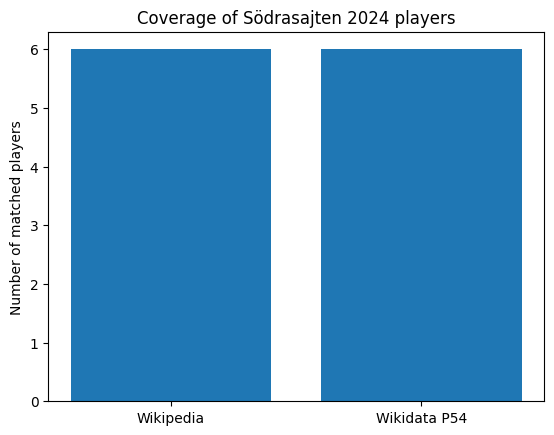

Wikipedia coverage: 6/49 (12.2%)
Wikidata coverage: 6/49 (12.2%)


In [9]:
import matplotlib.pyplot as plt

total = len(df)

wiki_matches = (df["Wikipedia category"] == "✅").sum()
wd_matches = df["Wikidata P54"].str.contains("wikidata").sum()

coverage = {
    "Wikipedia": wiki_matches,
    "Wikidata P54": wd_matches
}

plt.figure()
plt.bar(coverage.keys(), coverage.values())
plt.ylabel("Number of matched players")
plt.title("Coverage of Södrasajten 2024 players")
plt.show()

print(f"Wikipedia coverage: {wiki_matches}/{total} ({wiki_matches/total:.1%})")
print(f"Wikidata coverage: {wd_matches}/{total} ({wd_matches/total:.1%})")

In [10]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd

sparql = SPARQLWrapper("https://query.wikidata.org/sparql")

query = """
SELECT ?player ?playerLabel WHERE {
  ?player wdt:P54 wd:Q931714.
  
  FILTER NOT EXISTS {
    ?article schema:about ?player ;
             schema:isPartOf <https://sv.wikipedia.org/> .
  }
  
  SERVICE wikibase:label { bd:serviceParam wikibase:language "sv,en". }
}
"""

sparql.setQuery(query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

rows = []

for r in results["results"]["bindings"]:
    rows.append({
        "Player": r["playerLabel"]["value"],
        "Wikidata": r["player"]["value"]
    })

df_missing_svwiki = pd.DataFrame(rows).sort_values("Player")

df_missing_svwiki.head(20)

,Player,Wikidata
2,Aleksei Kangaskolkka,http://www.wikidata.org/entity/Q2356248
19,Allan Broling,http://www.wikidata.org/entity/Q130226401
15,Bengt Elofsson,http://www.wikidata.org/entity/Q126873318
20,Bertil Samuelsson,http://www.wikidata.org/entity/Q130226632
21,Birger Gustafsson,http://www.wikidata.org/entity/Q131283290
17,Bo Karlsson,http://www.wikidata.org/entity/Q130226217
30,Carl-Olof Claesson,http://www.wikidata.org/entity/Q132189912
3,Dustin Corea,http://www.wikidata.org/entity/Q5317088
0,Franz Weselik,http://www.wikidata.org/entity/Q323585
24,Fred Andersson,http://www.wikidata.org/entity/Q131823557


In [11]:
print(df_missing_svwiki.to_markdown(index=False))

| Player               | Wikidata                                  |
|:---------------------|:------------------------------------------|
| Aleksei Kangaskolkka | http://www.wikidata.org/entity/Q2356248   |
| Allan Broling        | http://www.wikidata.org/entity/Q130226401 |
| Bengt Elofsson       | http://www.wikidata.org/entity/Q126873318 |
| Bertil Samuelsson    | http://www.wikidata.org/entity/Q130226632 |
| Birger Gustafsson    | http://www.wikidata.org/entity/Q131283290 |
| Bo Karlsson          | http://www.wikidata.org/entity/Q130226217 |
| Carl-Olof Claesson   | http://www.wikidata.org/entity/Q132189912 |
| Dustin Corea         | http://www.wikidata.org/entity/Q5317088   |
| Franz Weselik        | http://www.wikidata.org/entity/Q323585    |
| Fred Andersson       | http://www.wikidata.org/entity/Q131823557 |
| Gary Richards        | http://www.wikidata.org/entity/Q15999960  |
| Gillis Skoog         | http://www.wikidata.org/entity/Q132158677 |
| Göran Berg           | http://ww

## leta spelare

In [12]:
import requests

r = requests.get("https://www.sodrasajten.se/wp-json/wp/v2/player?per_page=100")
print(r.status_code)
print(r)

404
<Response [404]>


In [13]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse
import time

BASE = "https://www.sodrasajten.se"
HEADERS = {"User-Agent": "Mozilla/5.0"}

visited = set()
to_visit = {BASE}
player_urls = set()

MAX_PAGES = 200  # säkerhetslimit

while to_visit and len(visited) < MAX_PAGES:
    url = to_visit.pop()
    visited.add(url)

    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        if r.status_code != 200:
            continue

        soup = BeautifulSoup(r.text, "html.parser")

        for a in soup.find_all("a", href=True):
            link = urljoin(BASE, a["href"])

            # endast interna länkar
            if BASE in link:
                if "/player/" in link:
                    spel_url = link.split("?")[0].rstrip("/")
                    player_urls.add(spel_url)
                    # print(spel_url)
                else:
                    if link not in visited:
                        to_visit.add(link)

        time.sleep(0.5)  # var snäll mot servern

    except Exception:
        continue

print("Hittade player-URLer:", len(player_urls))
list(player_urls)[:10]

Hittade player-URLer: 67


['https://www.sodrasajten.se/player/robin-book',
 'https://www.sodrasajten.se/player/julius-lindgren',
 'https://www.sodrasajten.se/player/jesper-svensson',
 'https://www.sodrasajten.se/player/fredric-fendrich',
 'https://www.sodrasajten.se/player/jesper-manns',
 'https://www.sodrasajten.se/player/dzenis-kozica',
 'https://www.sodrasajten.se/player/isak-ellbring',
 'https://www.sodrasajten.se/player/adrian-edqvist',
 'https://www.sodrasajten.se/player/igor-popanici',
 'https://www.sodrasajten.se/player/jacob-shamoun']

In [14]:
import re
from collections import Counter
from urllib.parse import urlparse

# Om du redan har en lista:
urls = list(player_urls)  # annars klistra in manuellt

# -------------------------------------------------
# 1. Deduplicera
# -------------------------------------------------

urls_unique = sorted(set(urls))

print("Totalt URLer:", len(urls))
print("Unika URLer:", len(urls_unique))

# -------------------------------------------------
# 2. Extrahera slug
# -------------------------------------------------

def extract_slug(url):
    slug = url.split("/player/")[1].rstrip("/")
    slug = re.sub(r"-\d+$", "", slug)  # ta bort -2, -3
    return slug

slugs = [extract_slug(u) for u in urls_unique]

# -------------------------------------------------
# 3. Slug → Namn
# -------------------------------------------------

def slug_to_name(slug):
    return slug.replace("-", " ").title()

players = [slug_to_name(s) for s in slugs]

print("Unika spelare:", len(players))
players[:20]

Totalt URLer: 67
Unika URLer: 67
Unika spelare: 67


['Adam Ben Lamin',
 'Adam Gemheden',
 'Adnan Maric',
 'Adrian Edqvist',
 'Alexander Eriksson',
 'Alexander Jallow',
 'Alexander Nilsson',
 'Amar Muhsin',
 'Amir Al Ammari',
 'Anas Al Asbahi',
 'Andreas Karlsson',
 'Anmar Kiwarkis',
 'Anton Cajtoft',
 'Anton Thorsson',
 'Arvid Eriksson',
 'Axel Edgren',
 'Benjamin Tannus',
 'Christian Azizsson',
 'Christoffer Hellstrom',
 'Colin Farnerud']

In [15]:
slug_counts = Counter([extract_slug(u) for u in urls])

most_common = slug_counts.most_common(15)

for slug, count in most_common:
    print(slug_to_name(slug), "→", count, "träffar")

Robin Book → 1 träffar
Julius Lindgren → 1 träffar
Jesper Svensson → 1 träffar
Fredric Fendrich → 1 träffar
Jesper Manns → 1 träffar
Dzenis Kozica → 1 träffar
Isak Ellbring → 1 träffar
Adrian Edqvist → 1 träffar
Igor Popanici → 1 träffar
Jacob Shamoun → 1 träffar
Anas Al Asbahi → 1 träffar
Felix Jakobsson → 1 träffar
Adnan Maric → 1 träffar
Axel Edgren → 1 träffar
Perparim Beqaj → 1 träffar


## Hur många finns i Wikidata?

In [16]:
wd_norm_set = set(wd_dict.keys())

players_norm = [normalize(p) for p in players]

in_wd = sum(1 for p in players_norm if p in wd_norm_set)
missing_wd = [players[i] for i, p in enumerate(players_norm) if p not in wd_norm_set]

print("Totala Södrasajten-spelare:", len(players))
print("Finns i Wikidata:", in_wd)
print("Saknas i Wikidata:", len(missing_wd))
print("Coverage:", f"{in_wd/len(players):.1%}")

Totala Södrasajten-spelare: 67
Finns i Wikidata: 39
Saknas i Wikidata: 28
Coverage: 58.2%


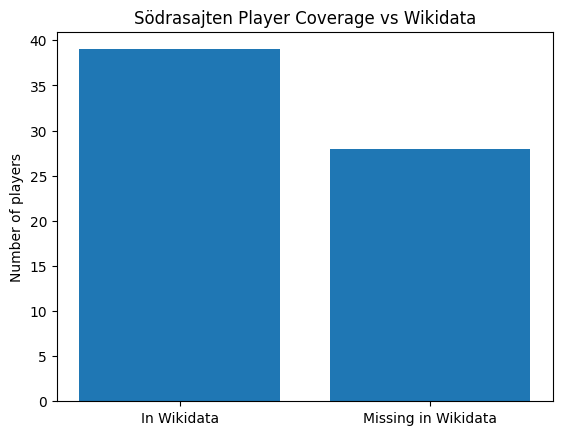

In [17]:
import matplotlib.pyplot as plt

total = len(players)
values = {
    "In Wikidata": in_wd,
    "Missing in Wikidata": len(missing_wd)
}

plt.figure()
plt.bar(values.keys(), values.values())
plt.ylabel("Number of players")
plt.title("Södrasajten Player Coverage vs Wikidata")
plt.show()

In [18]:
# End timer
end_time = datetime.now()
duration = end_time - start_time

print("\n--- Execution Summary ---")
print(f"End time:      {end_time:%Y-%m-%d %H:%M:%S}")
print(f"Duration:      {duration}")
print(f"Total seconds: {duration.total_seconds():.2f}")
print(f"Python ver:    {sys.version.split()[0]}")
print(f"Platform:      {platform.system()} {platform.release()}")
print(f"Process ID:    {os.getpid()}")


--- Execution Summary ---
End time:      2026-03-03 14:04:07
Duration:      0:02:45.598056
Total seconds: 165.60
Python ver:    3.12.2
Platform:      Darwin 25.3.0
Process ID:    54600
